# Topic 5 — Feature Selection: Filter Methods
**Covers:** Variance threshold · Correlation filtering · Chi-square test · ANOVA F-test ·
Mutual information · Combining scores into one view · `SelectKBest` / `SelectPercentile`
pipelines

**Dataset:** `data/raw/feature_selection_data.csv` — PrepEdge student dropout-risk data,
engineered with FOUR deliberate column types: genuinely predictive features, a near-zero-
variance column, redundant/duplicated columns, and pure-noise columns — so filter methods
have real junk to catch and real signal to keep.

---
## Explanation

Imagine cleaning out your toy box before a big trip — you can only take a few toys, so you
need FAST rules to decide what stays, without playing with every single toy first.

- **Variance threshold** = "if a toy never changes — like a rock that's always just a rock —
  it's boring and tells you nothing. Throw it out." (A column that's almost always the exact
  same value can't help tell students apart.)
- **Correlation filtering** = "if you have two toys that are basically twins — same toy car in
  two different boxes — you only need to pack one." (Two columns carrying near-identical
  information — keep one, drop the copy.)
- **Chi-square test** = a quick game: "does having a RED toy make you more likely to play
  OUTSIDE, or is that just random luck?" It checks if two categories (like toy color and
  indoor/outdoor play) are actually connected, or just coincidence.
- **ANOVA F-test** = "do kids who play with DIFFERENT toy types end up with really different
  amounts of ice cream as a reward, or about the same?" It checks if a NUMBER (ice cream
  amount) genuinely differs across CATEGORY groups (toy type).
- **Mutual information** = a more flexible detective that asks "does knowing about this toy
  tell me ANYTHING extra about how much fun you have?" — even if the relationship isn't a
  straight line, MI can still catch it, unlike a simple correlation check.
- **SelectKBest** = instead of deciding toy-by-toy, you tell a helper "just pack my TOP 5
  favorite toys, using whichever scoring rule I give you" — one command, done automatically.

## 1. WHY — Why filter BEFORE building any model?

**Filter methods** score each feature using simple statistics — computed independently of any
specific model — and are FAST: no model training required. They're a first-pass cleanup step,
run before the slower, model-based Wrapper methods (next session).

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/feature_selection_data.csv")
print(df.shape)
df.head()

(900, 11)


,student_id,attendance_pct,study_hours,prev_score,fee_delay_days,attendance_mode,attendance_pct_copy,study_minutes_scaled,random_numeric_noise,random_categorical_noise,at_risk
0,4001,87.6,5.9,86.2,2.5,Offline,87.8,350.2,72.5,B,0
1,4002,30.4,5.1,60.9,3.2,Offline,31.2,304.5,46.6,C,0
2,4003,70.4,6.3,31.7,26.4,Offline,69.9,381.5,37.1,D,1
3,4004,96.7,2.1,96.6,5.3,Offline,96.5,126.0,48.1,A,0
4,4005,56.3,9.8,55.8,12.0,Offline,56.7,587.5,46.8,B,1


## 2. Variance threshold — WHY / WHAT / HOW

**Why:** a column that's (almost) always the same value carries almost no information to
separate one student from another — no matter how it relates to the target.

**Manual check:** `attendance_mode` — count how often each value appears.

In [2]:
print(df["attendance_mode"].value_counts(normalize=True).round(4))

attendance_mode
Offline    0.9778
Online     0.0222
Name: proportion, dtype: float64


In [3]:
from sklearn.feature_selection import VarianceThreshold

# Numeric variance threshold needs numeric-encoded columns; quickly encode attendance_mode as 0/1
work = df.copy()
work["attendance_mode_bin"] = (work["attendance_mode"] == "Online").astype(int)

numeric_check_cols = ["attendance_pct", "study_hours", "prev_score", "fee_delay_days",
                       "attendance_mode_bin", "attendance_pct_copy", "study_minutes_scaled",
                       "random_numeric_noise"]

variances = work[numeric_check_cols].var().sort_values()
print("Variance per column (lowest = most 'boring'):")
print(variances.round(3))

selector = VarianceThreshold(threshold=0.01)   # drop near-constant columns
selector.fit(work[numeric_check_cols])
kept = np.array(numeric_check_cols)[selector.get_support()]
dropped = np.array(numeric_check_cols)[~selector.get_support()]
print("\nDropped (near-zero variance):", list(dropped))
print("Kept:", list(kept))

Variance per column (lowest = most 'boring'):
attendance_mode_bin         0.022
study_hours                 6.295
fee_delay_days             91.038
random_numeric_noise       98.963
attendance_pct_copy       217.217
attendance_pct            218.364
prev_score                218.658
study_minutes_scaled    22640.439
dtype: float64

Dropped (near-zero variance): []
Kept: [np.str_('attendance_pct'), np.str_('study_hours'), np.str_('prev_score'), np.str_('fee_delay_days'), np.str_('attendance_mode_bin'), np.str_('attendance_pct_copy'), np.str_('study_minutes_scaled'), np.str_('random_numeric_noise')]


**⚠️ Important caveat:** `VarianceThreshold` compares RAW variance across columns, so it is
only meaningful when columns are on comparable scales — a column measured in the thousands
will always have huge variance regardless of its actual informativeness. If your candidate
columns span very different scales (e.g. `attendance_pct` at 0-100 vs. `fee_delay_days` at
0-120 vs. a rupee-amount column at 0-100,000), scale them first (Unit 1, Session 5) before
applying a variance threshold, or the comparison is meaningless.

## 3. Correlation filtering — WHY / WHAT / HOW

**Why:** two nearly-identical columns don't each add new information — they just double-count
the same signal, and can destabilize some models (multicollinearity).

**Manual check:** compare `attendance_pct` with its near-duplicate `attendance_pct_copy`, and
`study_hours` with the unit-shifted duplicate `study_minutes_scaled`.

In [4]:
corr_matrix = work[["attendance_pct", "attendance_pct_copy", "study_hours",
                     "study_minutes_scaled", "prev_score", "fee_delay_days"]].corr()
corr_matrix.round(3)

,attendance_pct,attendance_pct_copy,study_hours,study_minutes_scaled,prev_score,fee_delay_days
attendance_pct,1.000,0.999,-0.013,-0.013,0.004,-0.003
attendance_pct_copy,0.999,1.000,-0.014,-0.013,0.004,-0.002
study_hours,-0.013,-0.014,1.000,1.000,-0.006,0.063
study_minutes_scaled,-0.013,-0.013,1.000,1.000,-0.007,0.064
prev_score,0.004,0.004,-0.006,-0.007,1.000,0.014
fee_delay_days,-0.003,-0.002,0.063,0.064,0.014,1.000


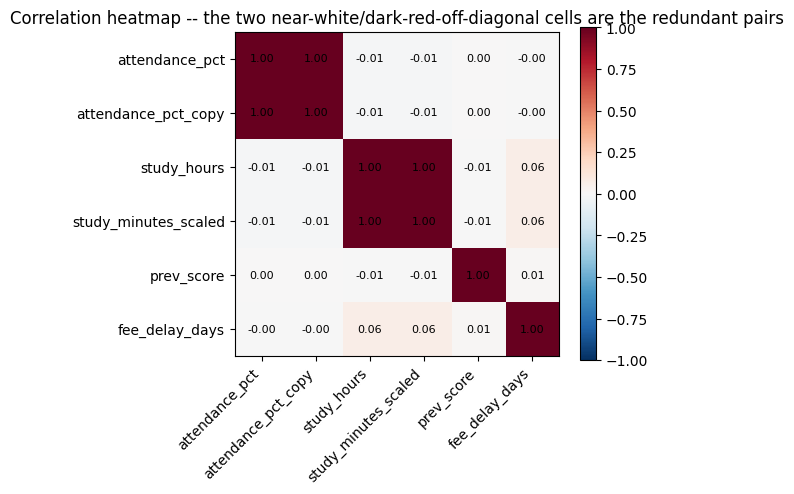

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns))); ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.columns))); ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation heatmap -- the two near-white/dark-red-off-diagonal cells are the redundant pairs")
plt.tight_layout()
plt.show()

In [6]:
# Automatic high-correlation detection: flag any pair above 0.9
threshold = 0.9
high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((cols[i], cols[j], round(corr_matrix.iloc[i, j], 3)))

print("Highly correlated pairs (keep one, drop the other):")
for a, b, r in high_corr_pairs:
    print(f"  {a}  <->  {b}   (r = {r})")

Highly correlated pairs (keep one, drop the other):
  attendance_pct  <->  attendance_pct_copy   (r = 0.999)
  study_hours  <->  study_minutes_scaled   (r = 1.0)


## 4. Chi-square test — WHY / WHAT / HOW (categorical feature vs. categorical/binary target)

**Why:** checks whether a categorical feature and the (categorical) target are statistically
associated, or whether any apparent link is just random noise.

**Manual intuition.** Build a contingency table of `random_categorical_noise` vs `at_risk` — if
the proportions of `at_risk` are roughly the SAME across categories A/B/C/D, chi-square will
correctly say "no real relationship."

In [7]:
contingency = pd.crosstab(df["random_categorical_noise"], df["at_risk"])
print(contingency)
print("\nAt-risk rate per category (should look similar across categories -- it's noise):")
print((contingency[1] / contingency.sum(axis=1)).round(3))

at_risk                     0   1
random_categorical_noise         
A                         151  68
B                         162  71
C                         165  70
D                         152  61

At-risk rate per category (should look similar across categories -- it's noise):
random_categorical_noise
A    0.311
B    0.305
C    0.298
D    0.286
dtype: float64


In [8]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

# chi2 in sklearn needs non-negative numeric input -- label-encode the categorical noise column
# and also test attendance_mode (near-constant, should also score low / be flagged separately)
cat_encoded = pd.DataFrame({
    "random_categorical_noise_enc": LabelEncoder().fit_transform(df["random_categorical_noise"]),
    "attendance_mode_enc": LabelEncoder().fit_transform(df["attendance_mode"]),
})

chi_scores, p_values = chi2(cat_encoded, df["at_risk"])
for col, score, p in zip(cat_encoded.columns, chi_scores, p_values):
    print(f"{col:32s} chi2={score:7.3f}  p-value={p:.4f}  "
          f"{'(likely NOT related -- high p-value)' if p > 0.05 else '(likely related)'}")

random_categorical_noise_enc     chi2=  0.262  p-value=0.6085  (likely NOT related -- high p-value)
attendance_mode_enc              chi2=  0.000  p-value=1.0000  (likely NOT related -- high p-value)


A high p-value (commonly > 0.05) means we CANNOT reject "no relationship" — exactly what
we'd expect for a column we built as pure random noise.

**⚠️ Important caveat:** `chi2` requires non-negative inputs (it's built on frequency counts).
Never feed it a raw signed numeric column (like `profit_margin_pct` from Topic 2, which can be
negative) — label/ordinal-encode categorical columns first, as we just did, and don't use
chi-square at all for genuinely continuous numeric features (that's what ANOVA F-test and
mutual information are for, next).

## 5. ANOVA F-test — WHY / WHAT / HOW (numeric feature vs. categorical target)

**Why:** checks whether a NUMERIC feature's mean genuinely differs across the target's groups
— useful for numeric features against a categorical/binary target like `at_risk`.

**Manual intuition.** Compare the mean `attendance_pct` for `at_risk=0` vs `at_risk=1` — a
real, predictive feature should show a clear gap between groups; `random_numeric_noise`
should show almost no gap.

In [9]:
for col in ["attendance_pct", "study_hours", "fee_delay_days", "random_numeric_noise"]:
    means = df.groupby("at_risk")[col].mean()
    print(f"{col:24s} mean(not at risk)={means[0]:8.2f}  mean(at risk)={means[1]:8.2f}  "
          f"gap={abs(means[0]-means[1]):.2f}")

attendance_pct           mean(not at risk)=   77.65  mean(at risk)=   67.40  gap=10.25
study_hours              mean(not at risk)=    5.95  mean(at risk)=    6.18  gap=0.23
fee_delay_days           mean(not at risk)=    9.31  mean(at risk)=   11.12  gap=1.81
random_numeric_noise     mean(not at risk)=   51.28  mean(at risk)=   50.59  gap=0.69


In [10]:
from sklearn.feature_selection import f_classif

numeric_candidates = ["attendance_pct", "study_hours", "prev_score", "fee_delay_days",
                       "random_numeric_noise", "attendance_pct_copy", "study_minutes_scaled"]
f_scores, p_values = f_classif(df[numeric_candidates], df["at_risk"])

result = pd.DataFrame({"feature": numeric_candidates, "F_score": f_scores.round(2), "p_value": p_values.round(4)})
result.sort_values("F_score", ascending=False)

,feature,F_score,p_value
0,attendance_pct,101.01,0.0000
5,attendance_pct_copy,100.43,0.0000
2,prev_score,27.63,0.0000
3,fee_delay_days,6.82,0.0092
1,study_hours,1.54,0.2145
6,study_minutes_scaled,1.54,0.2156
4,random_numeric_noise,0.91,0.3394


Notice `random_numeric_noise` scores near the bottom with a high p-value — exactly as it
should, since it was built with zero relationship to `at_risk`. The redundant copies
(`attendance_pct_copy`, `study_minutes_scaled`) score almost identically to their originals —
correlation filtering (Section 3) is what catches THOSE, not the F-test.

## 6. Mutual information — WHY / WHAT / HOW

**Why:** correlation and ANOVA/chi-square mostly catch LINEAR or simple group differences.
Mutual information (MI) can detect more general relationships (including non-linear ones),
by measuring how much knowing the feature reduces uncertainty about the target.

In [11]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(df[numeric_candidates], df["at_risk"], random_state=0)
mi_result = pd.DataFrame({"feature": numeric_candidates, "mutual_info": mi_scores.round(4)})
mi_result.sort_values("mutual_info", ascending=False)

,feature,mutual_info
5,attendance_pct_copy,0.0469
0,attendance_pct,0.0424
6,study_minutes_scaled,0.0184
4,random_numeric_noise,0.0064
1,study_hours,0.0056
2,prev_score,0.0000
3,fee_delay_days,0.0000


## 7. Combining multiple filter scores into one view

In practice, you rarely rely on a single filter statistic — different methods can disagree
slightly (especially on borderline features), so it's useful to line them all up side by side
before making a final call.

In [12]:
combined = result.merge(mi_result, on="feature")
combined = combined.rename(columns={"F_score": "ANOVA_F"})
combined["rank_ANOVA"] = combined["ANOVA_F"].rank(ascending=False)
combined["rank_MI"] = combined["mutual_info"].rank(ascending=False)
combined["avg_rank"] = combined[["rank_ANOVA", "rank_MI"]].mean(axis=1)
combined.sort_values("avg_rank")

,feature,ANOVA_F,p_value,mutual_info,rank_ANOVA,rank_MI,avg_rank
0,attendance_pct,101.01,0.0000,0.0424,1.0,2.0,1.50
5,attendance_pct_copy,100.43,0.0000,0.0469,2.0,1.0,1.50
6,study_minutes_scaled,1.54,0.2156,0.0184,5.5,3.0,4.25
2,prev_score,27.63,0.0000,0.0000,3.0,6.5,4.75
3,fee_delay_days,6.82,0.0092,0.0000,4.0,6.5,5.25
1,study_hours,1.54,0.2145,0.0056,5.5,5.0,5.25
4,random_numeric_noise,0.91,0.3394,0.0064,7.0,4.0,5.50


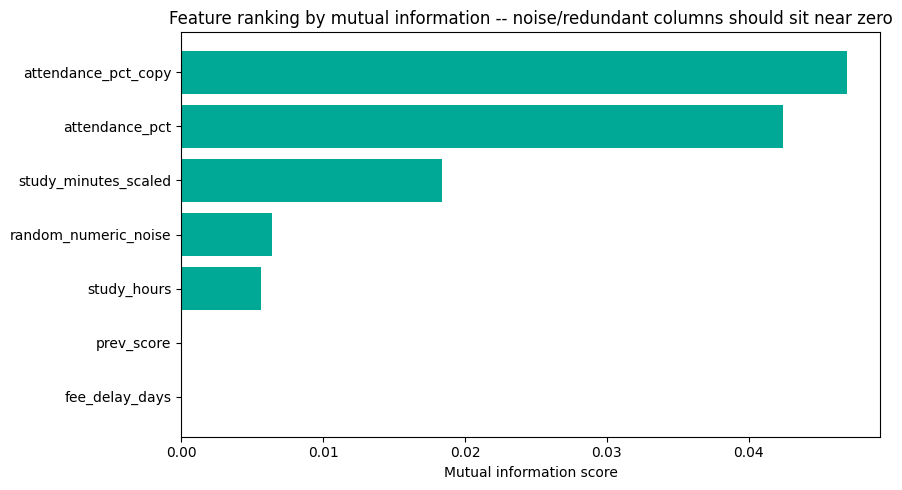

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sorted_combined = combined.sort_values("mutual_info", ascending=True)
ax.barh(sorted_combined["feature"], sorted_combined["mutual_info"], color="#00A896")
ax.set_xlabel("Mutual information score")
ax.set_title("Feature ranking by mutual information -- noise/redundant columns should sit near zero")
plt.tight_layout()
plt.show()

## 8. Automating the whole thing with `SelectKBest` / `SelectPercentile`

Rather than manually reading scores off a table, sklearn's selector classes let you plug in
ANY scoring function (`f_classif`, `chi2`, `mutual_info_classif`, ...) and automatically keep
either the top `k` features or the top `percentile`%.

In [14]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, f_classif

# Keep the top 4 features by ANOVA F-score
selector_kbest = SelectKBest(score_func=f_classif, k=4)
selector_kbest.fit(df[numeric_candidates], df["at_risk"])
print("SelectKBest(k=4) keeps:", list(np.array(numeric_candidates)[selector_kbest.get_support()]))

# Keep the top 50% of features by the same score
selector_pct = SelectPercentile(score_func=f_classif, percentile=50)
selector_pct.fit(df[numeric_candidates], df["at_risk"])
print("SelectPercentile(50%) keeps:", list(np.array(numeric_candidates)[selector_pct.get_support()]))

SelectKBest(k=4) keeps: [np.str_('attendance_pct'), np.str_('prev_score'), np.str_('fee_delay_days'), np.str_('attendance_pct_copy')]
SelectPercentile(50%) keeps: [np.str_('attendance_pct'), np.str_('prev_score'), np.str_('attendance_pct_copy')]


In [15]:
# These selectors drop cleanly into an sklearn Pipeline, exactly like Unit 1's
# preprocessing pipelines -- fit on train, apply identically to test/inference
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score

pipe = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=4)),
    ("model", LogisticRegression(max_iter=1000)),
])

scores = cross_val_score(pipe, df[numeric_candidates], df["at_risk"], cv=5, scoring="roc_auc")
print(f"Pipeline (SelectKBest -> LogisticRegression) mean CV ROC-AUC: {scores.mean():.3f}")

Pipeline (SelectKBest -> LogisticRegression) mean CV ROC-AUC: 0.727


## 9. Recap — Filter method decision guide

| Method | Feature type | Target type | Catches | Scale-sensitive? |
|---|---|---|---|---|
| Variance threshold | Any (numeric-encoded) | N/A (no target needed) | Near-constant / boring columns | **Yes** — scale features first if ranges differ |
| Correlation filtering | Numeric | N/A (feature-vs-feature) | Redundant/duplicated columns | No |
| Chi-square | Categorical | Categorical | Category-vs-category association | Needs non-negative input |
| ANOVA F-test | Numeric | Categorical | Whether group means genuinely differ | No |
| Mutual information | Numeric or categorical | Either | General (incl. non-linear) dependence | No |
| `SelectKBest`/`SelectPercentile` | Wraps any of the above | Either | Automates "keep top N/percentile" | Inherits from the scoring function used |

**ELI5 recap:** throw out the boring unchanging toy (variance), don't pack two identical toys
(correlation), check if toy color really connects to indoor/outdoor play (chi-square), check
if reward amount really differs by toy type (ANOVA), use a flexible detective for anything
trickier (mutual information), and let a helper automatically pack your top-N favorite toys
using whichever rule you choose (`SelectKBest`).